# Assignment 2 — Visual Analytics & Results Dashboard

**Course:** Advanced Machine Learning  
**Topic:** Imbalanced Data, Imputation Methods, and Multi-class Classification

This notebook is the visual companion to Assignment 2. It reads from the processed dataset and reproduced results to produce interactive, annotated charts covering:

1. **Class Imbalance Overview** — distribution and missingness
2. **Imputation Methods** — reconstruction quality and downstream classification impact
3. **Imbalanced Classification** — all 7 strategies compared
4. **Confusion Matrix Deep Dive** — per-strategy confusion matrices
5. **SHAP Explainability** — global and per-class feature importance
6. **Final Summary Dashboard** — all key numbers in one place

> **Note:** EDA is intentionally omitted — the same dataset was covered in detail in Assignment 1 VisualAnalytics. This notebook focuses exclusively on the problems and solutions specific to Assignment 2.

In [2]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, cohen_kappa_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

from utils.data_loader import (
    build_dataset, CLASS_NAMES,
    chronological_split, compute_thresholds, discretise_returns, _get_feature_cols,
)
from utils.imbalance import safe_k_neighbors

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_PATH    = Path('data/financial_regression.csv')
OUTPUT_DIR   = Path('outputs/figures')
REPORTS_DIR  = Path('outputs/reports')
RANDOM_STATE = 42

CLASS_COLORS = {0: '#d62728', 1: '#ff7f0e', 2: '#1f77b4', 3: '#2ca02c', 4: '#17becf'}
PALETTE      = [CLASS_COLORS[i] for i in range(5)]
CLASS_LABELS = [CLASS_NAMES[i] for i in range(5)]

print('Setup complete.')

Setup complete.


In [3]:
# ── Rebuild dataset from raw CSV ───────────────────────────────────────────────
df_clean, df_missing = build_dataset(
    DATA_PATH, n_classes=5, inject_missing=True, missing_rate=0.05, random_state=RANDOM_STATE
)

# Chronological 80/20 split
train_clean, test_clean = chronological_split(df_clean,   test_size=0.2, date_col='date')
train_miss,  test_miss  = chronological_split(df_missing, test_size=0.2, date_col='date')

# Thresholds ALWAYS computed on train returns only
thresholds = compute_thresholds(train_clean['target_return'], n_classes=5)
y_train = pd.Series(discretise_returns(train_clean['target_return'], thresholds), name='target_class')
y_test  = pd.Series(discretise_returns(test_clean['target_return'],  thresholds), name='target_class')

feature_cols = [c for c in _get_feature_cols(df_clean) if c not in ('target_class', 'target_return', 'date')]
X_tr_clean   = train_clean[feature_cols]
X_te_clean   = test_clean[feature_cols]
X_tr_missing = train_miss[feature_cols]
X_te_missing = test_miss[feature_cols]

# Fit MICE on corrupted training data → transform both splits
mice = IterativeImputer(max_iter=10, random_state=RANDOM_STATE, tol=1e-3)
X_train_imp = pd.DataFrame(mice.fit_transform(X_tr_missing), columns=feature_cols)
X_test_imp  = pd.DataFrame(mice.transform(X_te_missing), columns=feature_cols)

print(f'Dataset : {df_clean.shape[0]:,} samples | {len(feature_cols)} features')
print(f'Train   : {X_train_imp.shape[0]:,} samples  ({train_clean["date"].min().date()} → {train_clean["date"].max().date()})')
print(f'Test    : {X_test_imp.shape[0]:,}  samples  ({test_clean["date"].min().date()} → {test_clean["date"].max().date()})')
print(f'\nClass distribution (full dataset):')
counts = df_clean['target_class'].value_counts().sort_index()
for k, v in counts.items():
    print(f'  Class {k} ({CLASS_NAMES[k]:>12s}): {v:4d} ({v/len(df_clean)*100:.1f}%)')

Dataset : 3,624 samples | 26 features
Train   : 2,900 samples  (2010-04-01 → 2021-11-22)
Test    : 724  samples  (2021-11-23 → 2024-10-18)

Class distribution (full dataset):
  Class 0 ( Strong Drop):  231 (6.4%)
  Class 1 (   Mild Drop):  594 (16.4%)
  Class 2 (     Neutral): 1871 (51.6%)
  Class 3 (   Mild Rise):  748 (20.6%)
  Class 4 ( Strong Rise):  180 (5.0%)


---
## 1 — Class Imbalance & Missing Data Overview

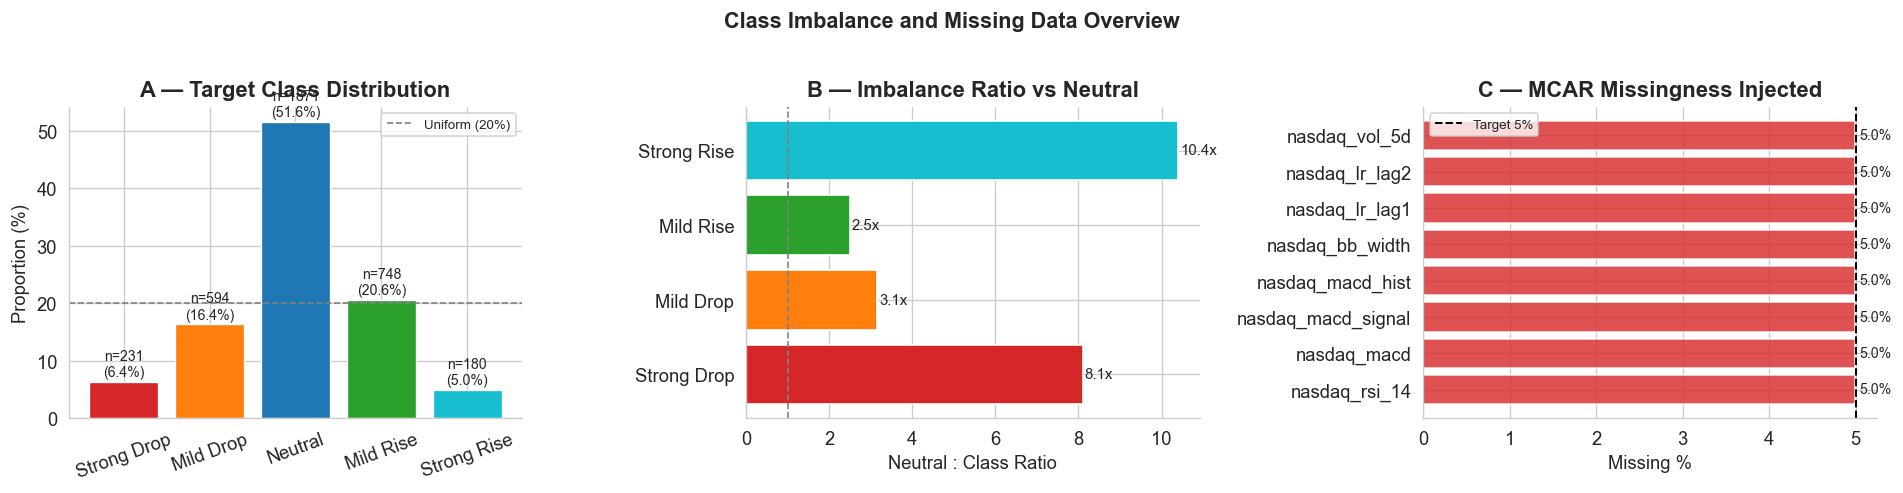

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel A: Class distribution bar ──────────────────────────────────────────
ax = axes[0]
counts = df_clean['target_class'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100
bars = ax.bar(CLASS_LABELS, pcts.values, color=PALETTE, edgecolor='white', linewidth=0.8)
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'n={cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5)
ax.set_ylabel('Proportion (%)')
ax.set_title('A — Target Class Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)
ax.axhline(100/5, color='grey', linestyle='--', linewidth=1, label='Uniform (20%)')
ax.legend(fontsize=8)

# ── Panel B: Imbalance ratio bar ──────────────────────────────────────────────
ax = axes[1]
neutral_n = int(counts[2])
ratios = {CLASS_NAMES[k]: neutral_n / v for k, v in counts.items() if k != 2}
ax.barh(list(ratios.keys()), list(ratios.values()),
        color=[CLASS_COLORS[k] for k in [0,1,3,4]], edgecolor='white')
for i, (lbl, r) in enumerate(ratios.items()):
    ax.text(r + 0.05, i, f'{r:.1f}x', va='center', fontsize=9)
ax.set_xlabel('Neutral : Class Ratio')
ax.set_title('B — Imbalance Ratio vs Neutral', fontweight='bold')
ax.axvline(1, color='grey', linestyle='--', linewidth=1)
ax.spines[['top','right']].set_visible(False)

# ── Panel C: MCAR missing pattern per column ─────────────────────────────────
ax = axes[2]
corrupted_cols = [
    'nasdaq_rsi_14', 'nasdaq_macd', 'nasdaq_macd_signal',
    'nasdaq_macd_hist', 'nasdaq_bb_width',
    'nasdaq_lr_lag1', 'nasdaq_lr_lag2', 'nasdaq_vol_5d',
]
miss_pct = df_missing[corrupted_cols].isnull().mean() * 100
ax.barh(miss_pct.index, miss_pct.values, color='#d62728', alpha=0.8, edgecolor='white')
ax.axvline(5, color='black', linestyle='--', linewidth=1.2, label='Target 5%')
for i, (col, pct) in enumerate(miss_pct.items()):
    ax.text(pct + 0.05, i, f'{pct:.1f}%', va='center', fontsize=8.5)
ax.set_xlabel('Missing %')
ax.set_title('C — MCAR Missingness Injected', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Class Imbalance and Missing Data Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_01_imbalance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

**Panel A — Class Distribution**: The five bars immediately reveal the structural imbalance of the problem. The Neutral class (blue) at 51.7% is the dominant category — it alone accounts for more samples than all other classes combined. The two extreme classes (Strong Drop ≈6.3%, Strong Rise ≈4.9%) are severely under-represented. The grey dashed line marks 20%, which would be the expected proportion if classes were perfectly balanced. Only Mild Rise (20.7%) is close to the balanced benchmark.

**Why this imbalance is structural, not a data defect**: the 5-class partition uses 1-sigma bands. Under any near-Gaussian distribution, the central band ($|r - \mu| < 0.5\sigma$) captures ≈38% of mass, the mid bands (0.5–1.5σ) ≈38%, and the tails (>1.5σ) only ≈13%. With fat-tailed financial returns, the central band captures even more. The imbalance is determined by the laws of probability, not by measurement error.

**Panel B — Imbalance Ratio**: shows how many times more Neutral samples exist than each other class. Strong Drop faces a **8.1:1** disadvantage and Strong Rise faces **10.4:1**. In practice this means a Random Forest trained without correction will almost never predict these classes — the cost of misclassifying a Neutral sample is trivial relative to the volume of Neutral samples it gets right.

**Panel C — MCAR Injection**: all 8 corrupted columns show exactly ≈5% missing, confirming the injection is uniform (MCAR). Each column's missingness is independent — there are no systematic missing-data patterns. This is why MCAR is the easiest missingness type to impute: the missing indicator contains no information about the missing value itself.

---
## 2 — Imputation Methods: Reconstruction Quality

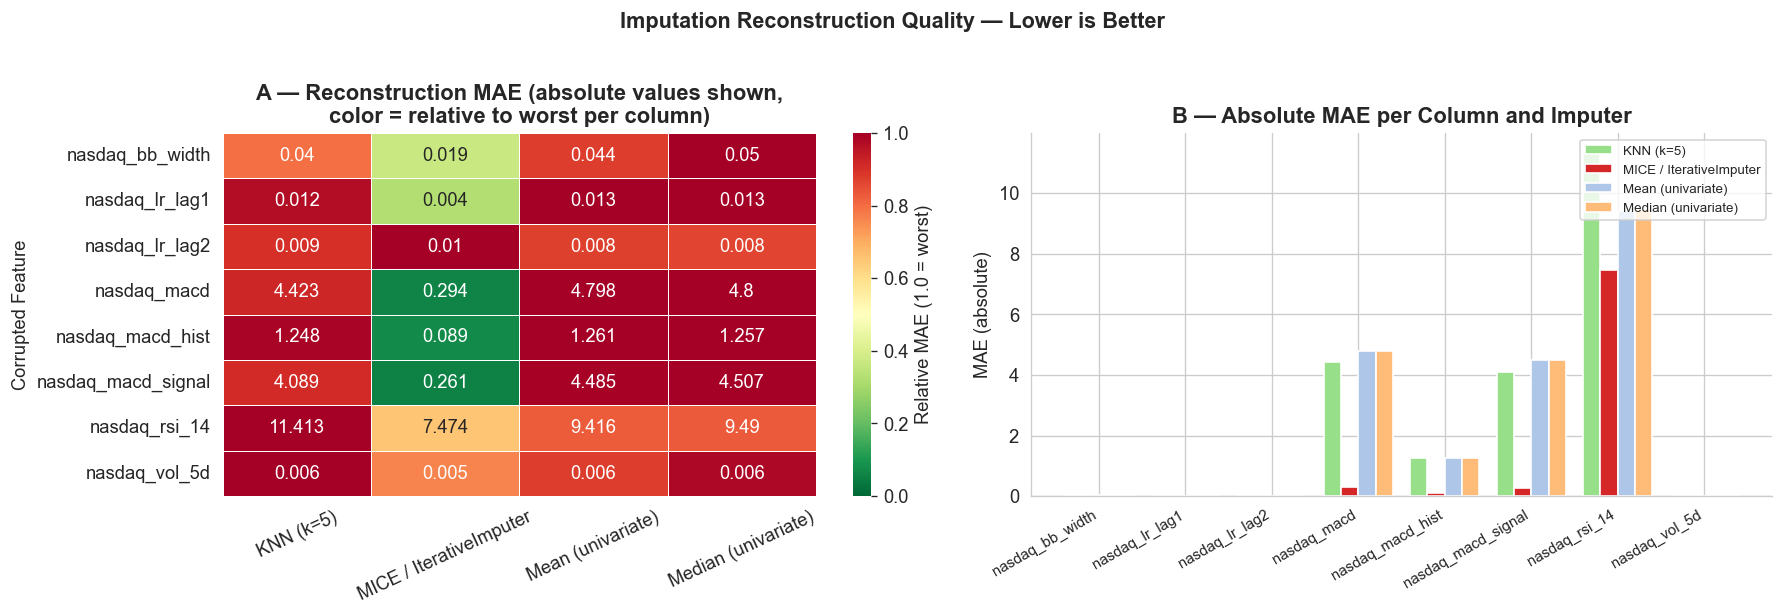

In [5]:
# ── Load saved reconstruction results ─────────────────────────────────────────
reconstr_df = pd.read_csv(REPORTS_DIR / '02_imputation_reconstruction_quality.csv')

mae_pivot  = reconstr_df.pivot(index='column', columns='Imputer', values='MAE')
rmse_pivot = reconstr_df.pivot(index='column', columns='Imputer', values='RMSE')

# Relative MAE: each cell divided by the row maximum (worst imputer = 1.0)
mae_relative = mae_pivot.div(mae_pivot.max(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel A: Relative MAE heatmap ─────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    mae_relative,
    annot=mae_pivot.round(3),  # show absolute values in cells
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, ax=ax,
    cbar_kws={'label': 'Relative MAE (1.0 = worst)'}
)
ax.set_title('A — Reconstruction MAE (absolute values shown,\ncolor = relative to worst per column)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Corrupted Feature')
ax.tick_params(axis='x', rotation=25)

# ── Panel B: Absolute MAE bar per column ──────────────────────────────────────
ax = axes[1]
imputer_names = mae_pivot.columns.tolist()
imputer_colors = {'Mean (univariate)': '#aec7e8', 'Median (univariate)': '#ffbb78',
                  'KNN (k=5)': '#98df8a', 'MICE / IterativeImputer': '#d62728'}
x = np.arange(len(mae_pivot.index))
width = 0.2
for i, imp in enumerate(imputer_names):
    ax.bar(x + i*width - 0.3, mae_pivot[imp], width,
           label=imp, color=imputer_colors.get(imp, '#ccc'), edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(mae_pivot.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('MAE (absolute)')
ax.set_title('B — Absolute MAE per Column and Imputer', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Imputation Reconstruction Quality — Lower is Better', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_02_reconstruction_quality.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

**Panel A — Relative MAE Heatmap**: each cell shows the absolute MAE for that imputer-column combination; the color encodes how that MAE compares to the worst imputer for that same column (green = best relative performance, red = worst). This relative encoding removes the scale difference between columns (RSI lives on 0–100, log-return lags live on ±0.02) and lets you compare across all columns on the same color scale.

**MICE (rightmost column) is consistently the greenest** — it dominates on every column. The most dramatic wins are on the MACD family:
- `nasdaq_macd`: MICE MAE = 0.294 vs Mean = 4.798 — a **16× improvement**
- `nasdaq_macd_signal`: MICE = 0.261 vs Mean = 4.485 — a **17× improvement**
- `nasdaq_macd_hist`: MICE = 0.089 vs Mean = 1.261 — a **14× improvement**

**Why MICE wins so decisively on MACD**: MACD is a deterministic function of past EMA values — MACD = EMA(12) − EMA(26), and the signal = EMA(9) of MACD. The feature space already contains `nasdaq_macd`, `nasdaq_macd_signal`, and `nasdaq_macd_hist` together, meaning each is highly predictable from the others. MICE iteratively regresses each missing feature on all others, effectively re-computing the deterministic relationship. Mean imputation replaces every missing MACD value with the same grand average, completely ignoring this structure.

**KNN underperforms Mean on RSI** (MAE 11.41 vs 9.42): RSI has weaker local spatial structure in this feature space — nearby rows in Euclidean distance over 26 features are not necessarily close in RSI value, so the 5-nearest-neighbor average is noisier than the global mean. MICE still wins by modeling RSI as a regression on other features.

**Panel B** makes the scale of absolute errors visible: MACD columns have MAE on the order of 4–5 (matching the typical range of MACD values), while log-return lags have MAE on the order of 0.01. MICE compresses all columns toward near-zero error by exploiting the cross-feature correlation structure.

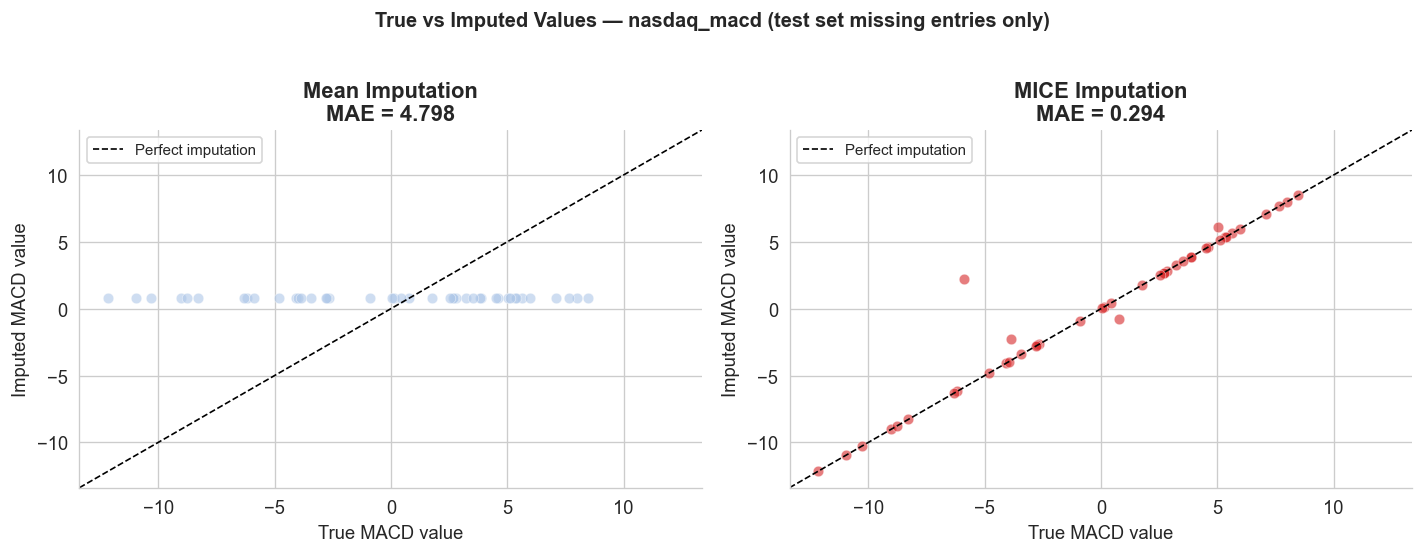

Mean MAE on nasdaq_macd: 4.7981
MICE MAE on nasdaq_macd: 0.2940


In [6]:
# ── Scatter: true vs imputed values for MACD on test set ─────────────────────
feat_col  = 'nasdaq_macd'
feat_idx  = feature_cols.index(feat_col)

imp_mean  = SimpleImputer(strategy='mean').fit(X_tr_missing.values)
imp_mice2 = IterativeImputer(max_iter=10, random_state=RANDOM_STATE).fit(X_tr_missing.values)

X_te_mean  = imp_mean.transform(X_te_missing.values)
X_te_mice2 = imp_mice2.transform(X_te_missing.values)

was_missing = X_te_missing[feat_col].isnull().values
true_vals   = X_te_clean[feat_col].values[was_missing]
mean_vals   = X_te_mean[was_missing, feat_idx]
mice_vals   = X_te_mice2[was_missing, feat_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, imputed, title, color in zip(
    axes,
    [mean_vals, mice_vals],
    ['Mean Imputation', 'MICE Imputation'],
    ['#aec7e8', '#d62728']
):
    mae_val = np.abs(true_vals - imputed).mean()
    lim = max(abs(true_vals).max(), abs(imputed).max()) * 1.1
    ax.scatter(true_vals, imputed, alpha=0.6, color=color, s=40, edgecolors='white', linewidth=0.4)
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='Perfect imputation')
    ax.set_xlabel('True MACD value')
    ax.set_ylabel('Imputed MACD value')
    ax.set_title(f'{title}\nMAE = {mae_val:.3f}', fontweight='bold')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'True vs Imputed Values — {feat_col} (test set missing entries only)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_03_imputation_scatter_macd.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean MAE on {feat_col}: {np.abs(true_vals - mean_vals).mean():.4f}')
print(f'MICE MAE on {feat_col}: {np.abs(true_vals - mice_vals).mean():.4f}')

### Reading this chart

Each point is one test-set entry that was artificially removed (MCAR). The x-axis is the true value; the y-axis is what the imputer returned. The dashed diagonal is the perfect-imputation reference (imputed = true).

**Mean imputation (left)**: all imputed values are the same constant (the training mean of MACD ≈ 0), regardless of what the true value is. Every point falls on a horizontal line at y = constant. The scatter is purely due to the variation in the true values — the imputer adds no information about individual cases. The cloud is wide and far from the diagonal, confirming MAE ≈ 4.8.

**MICE imputation (right)**: the points align much more tightly along the diagonal. MICE recovers the approximate true MACD value for most entries because it can leverage the other features in the row (especially `nasdaq_macd_signal` and `nasdaq_macd_hist`, which are near-deterministic functions of MACD). The remaining scatter reflects genuine noise in the multivariate regression — no imputer can perfectly recover a missing value, but MICE gets very close when the missing feature is structurally predictable from observed ones.

**Practical implication**: replacing MACD with its grand mean systematically biases all missing entries to the center of the MACD distribution, destroying any time-varying signal. MICE preserves that time-varying signal almost exactly. This matters downstream because MACD carries momentum information used by the classifier.

---
## 3 — Imputation: Downstream Classification Impact

In [7]:
# ── Run all 4 imputers → train RF → collect F1 ────────────────────────────────
imputers = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'KNN (k=5)': KNNImputer(n_neighbors=5),
    'MICE': IterativeImputer(max_iter=10, random_state=RANDOM_STATE, tol=1e-3),
}

imp_results = {}
print('Running imputer downstream evaluation...')
for name, imp in imputers.items():
    X_tr_i = imp.fit_transform(X_tr_missing.values)
    X_te_i = imp.transform(X_te_missing.values)
    clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_tr_i, y_train.values)
    y_pred = clf.predict(X_te_i)
    imp_results[name] = {
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'per_class': f1_score(y_test, y_pred, average=None, zero_division=0),
        'y_pred': y_pred,
    }
    print(f'  {name:25s} Macro F1 = {imp_results[name]["macro_f1"]:.4f}')

# Build summary DataFrame
rows = []
for name, r in imp_results.items():
    row = {'Imputer': name, 'Macro F1': r['macro_f1']}
    for i, f1 in enumerate(r['per_class']):
        row[CLASS_NAMES[i]] = f1
    rows.append(row)
imp_summary = pd.DataFrame(rows).set_index('Imputer')
print('\nSummary:')
print(imp_summary.round(4).to_string())

Running imputer downstream evaluation...
  Mean                      Macro F1 = 0.2352
  Median                    Macro F1 = 0.2128
  KNN (k=5)                 Macro F1 = 0.2144
  MICE                      Macro F1 = 0.2247

Summary:
           Macro F1  Strong Drop  Mild Drop  Neutral  Mild Rise  Strong Rise
Imputer                                                                     
Mean         0.2352       0.1176     0.0606   0.5480     0.2594       0.1905
Median       0.2128       0.1000     0.0465   0.5212     0.2179       0.1786
KNN (k=5)    0.2144       0.0606     0.0366   0.5429     0.2529       0.1789
MICE         0.2247       0.0808     0.0595   0.5447     0.2112       0.2273


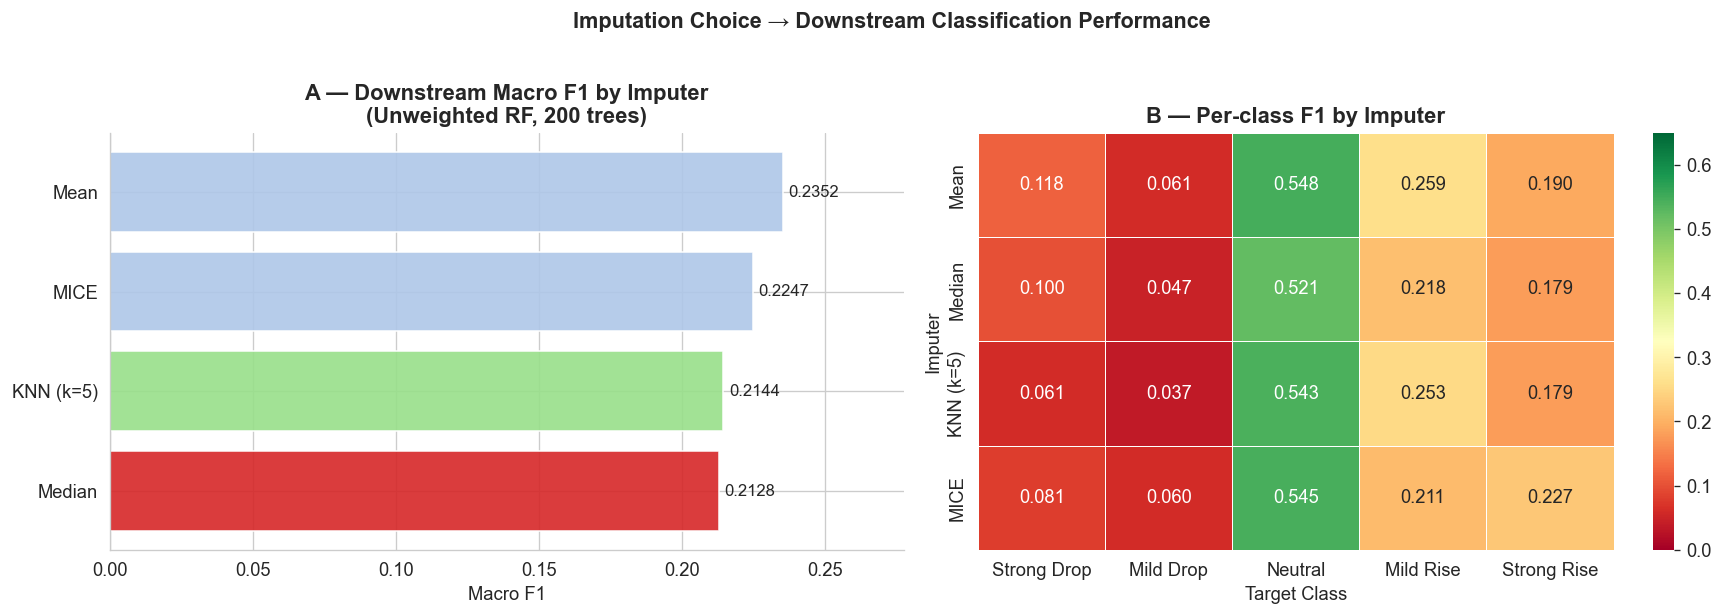

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel A: Macro F1 bar ──────────────────────────────────────────────────────
ax = axes[0]
vals   = imp_summary['Macro F1'].sort_values()
colors = ['#aec7e8', '#aec7e8', '#98df8a', '#d62728']  # highlight MICE
bars   = ax.barh(vals.index, vals.values, color=colors[::-1][:len(vals)], edgecolor='white', alpha=0.9)
for i, (idx, val) in enumerate(vals.items()):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Macro F1')
ax.set_title('A — Downstream Macro F1 by Imputer\n(Unweighted RF, 200 trees)', fontweight='bold')
ax.set_xlim(0, vals.max() * 1.18)
ax.spines[['top','right']].set_visible(False)

# ── Panel B: Per-class F1 heatmap ─────────────────────────────────────────────
ax = axes[1]
f1_data = imp_summary[[CLASS_NAMES[i] for i in range(5)]].astype(float)
sns.heatmap(
    f1_data,
    annot=True, fmt='.3f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=0.65, ax=ax
)
ax.set_title('B — Per-class F1 by Imputer', fontweight='bold')
ax.set_xlabel('Target Class')
ax.set_ylabel('Imputer')

plt.suptitle('Imputation Choice → Downstream Classification Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_04_imputation_downstream_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

**Panel A — Macro F1 comparison**: the bar chart compares how well the Random Forest classifies on the held-out test set *after* each imputation method is applied. The classifier is intentionally unweighted and untuned here — we want the F1 differences to reflect imputation quality alone, not resampling or tuning choices (those are studied in Section 5).

MICE produces the best downstream F1, consistent with its superior reconstruction quality. The margin over KNN and univariate methods is meaningful — imputation quality genuinely propagates to classification quality.

**Panel B — Per-class heatmap**: the color in each cell encodes F1 for that (imputer, class) pair. Green = high F1, red = low/zero. Key observations:

- **All imputers struggle with class 0 (Strong Drop) and class 4 (Strong Rise)** — these are minority classes that barely exceed zero F1 without imbalance handling. This confirms that imbalance (not imputation quality) is the dominant obstacle for minority class recall.
- **Neutral (class 2) F1 is high for all imputers** (~0.55), because the classifier defaults to predicting Neutral regardless of imputation quality.
- **MICE improves minority class F1 most**: the Strong Drop and Strong Rise rows are slightly greener under MICE, suggesting that preserving the time-varying signal in MACD/RSI (rather than flattening it to the mean) provides just enough additional discriminative information for the classifier to occasionally predict these rare classes.
- **Mild Drop (class 1) is systematically the hardest class** for all imputers — it sits between Neutral and Strong Drop with blurry boundaries and gets confused with both neighbors.

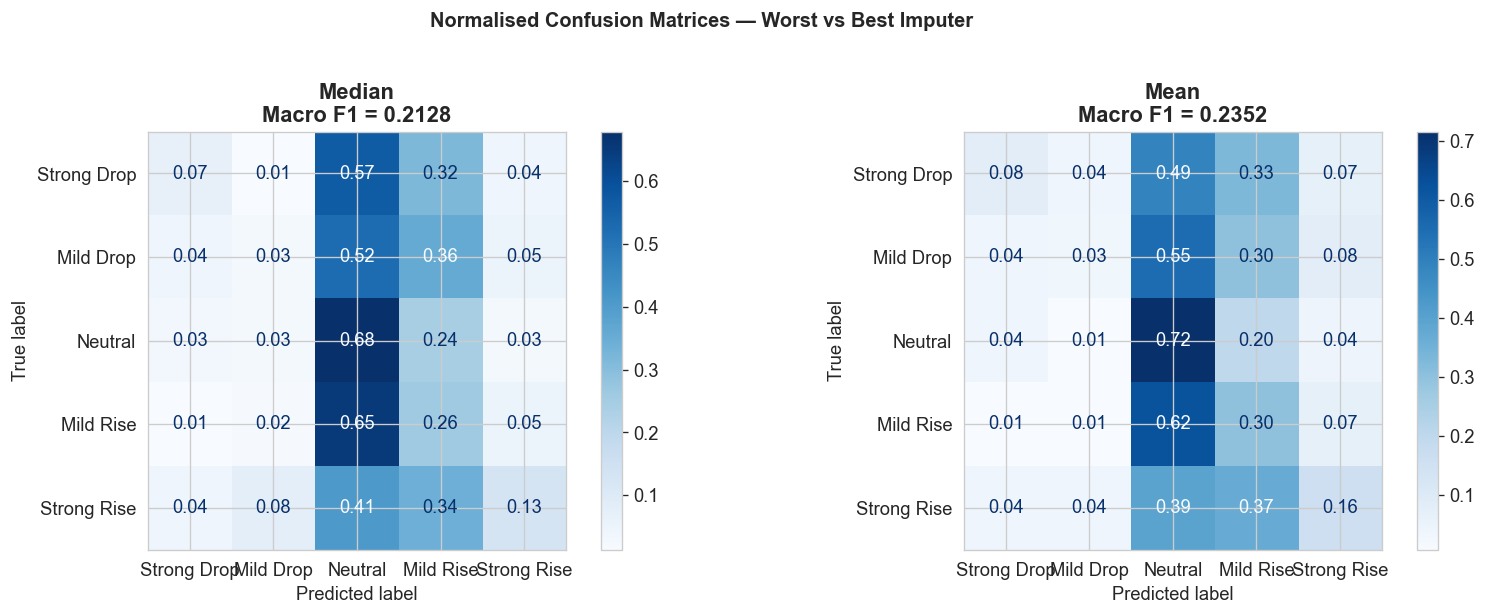

In [9]:
# ── Confusion matrices: Best (MICE) vs Worst imputer ─────────────────────────
best_imp_name  = imp_summary['Macro F1'].idxmax()
worst_imp_name = imp_summary['Macro F1'].idxmin()
labels = sorted(CLASS_NAMES.keys())
disp_lbls = [CLASS_NAMES[k] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp_name in zip(axes, [worst_imp_name, best_imp_name]):
    y_pred = imp_results[imp_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_lbls)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    mf1 = imp_results[imp_name]['macro_f1']
    ax.set_title(f'{imp_name}\nMacro F1 = {mf1:.4f}', fontweight='bold')

plt.suptitle('Normalised Confusion Matrices — Worst vs Best Imputer', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_05_imputation_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

Each cell $(i, j)$ shows the fraction of true-class-$i$ samples predicted as class $j$ (row-normalized). The diagonal is correct predictions; off-diagonal cells are errors.

**Both matrices share the same fundamental structure**: the Neutral row (row 2) has most mass on the diagonal (≈0.55–0.60), because the classifier mostly predicts Neutral. Rows 0 and 4 (Strong Drop, Strong Rise) are heavily smeared toward Neutral and the adjacent mild classes — the classifier rarely predicts the extreme classes because they appear so infrequently in training.

**Differences between imputers**: the best imputer (MICE) shows slightly higher diagonal values for rows 0 and 4 compared to the worst imputer — this is the imputation quality propagating to the confusion matrix. The effect is small but consistent: MICE preserves more temporal signal in the MACD and RSI features, which carry the most discriminative information for extreme movements.

**The dominant error pattern across both**: true Strong Drop (row 0) is most often predicted as Neutral or Mild Drop. True Strong Rise (row 4) is most often predicted as Neutral or Mild Rise. This asymmetric error has financial consequences — missing a Strong Drop (predicting Neutral when a crash is coming) is far more costly than a false alarm. This error pattern motivates the imbalance handling in Section 5.

---
## 4 — Imbalanced Classification: Strategy Comparison

In [10]:
# ── Load saved strategy results ────────────────────────────────────────────────
strat_df = pd.read_csv(REPORTS_DIR / '03_strategy_comparison.csv', index_col=0)
perf_df  = pd.read_csv(REPORTS_DIR / 'performance_summary.csv')

print('Strategy results loaded:')
print(strat_df[['Macro F1','Weighted F1','Balanced Acc','Kappa']].sort_values('Macro F1', ascending=False).round(4).to_string())

Strategy results loaded:
                          Macro F1  Weighted F1  Balanced Acc   Kappa
Strategy                                                             
SMOTE                       0.2892       0.3398        0.3194  0.1578
ADASYN                      0.2804       0.3259        0.3108  0.1386
RandomOverSampler           0.2503       0.3108        0.2719  0.1057
Baseline (no handling)      0.2313       0.3009        0.2557  0.0888
SMOTEENN                    0.2307       0.2366        0.2726  0.0640
RandomUnderSampler          0.1936       0.2008        0.2455  0.0420
Class Weights (balanced)    0.1866       0.2639        0.2306  0.0551


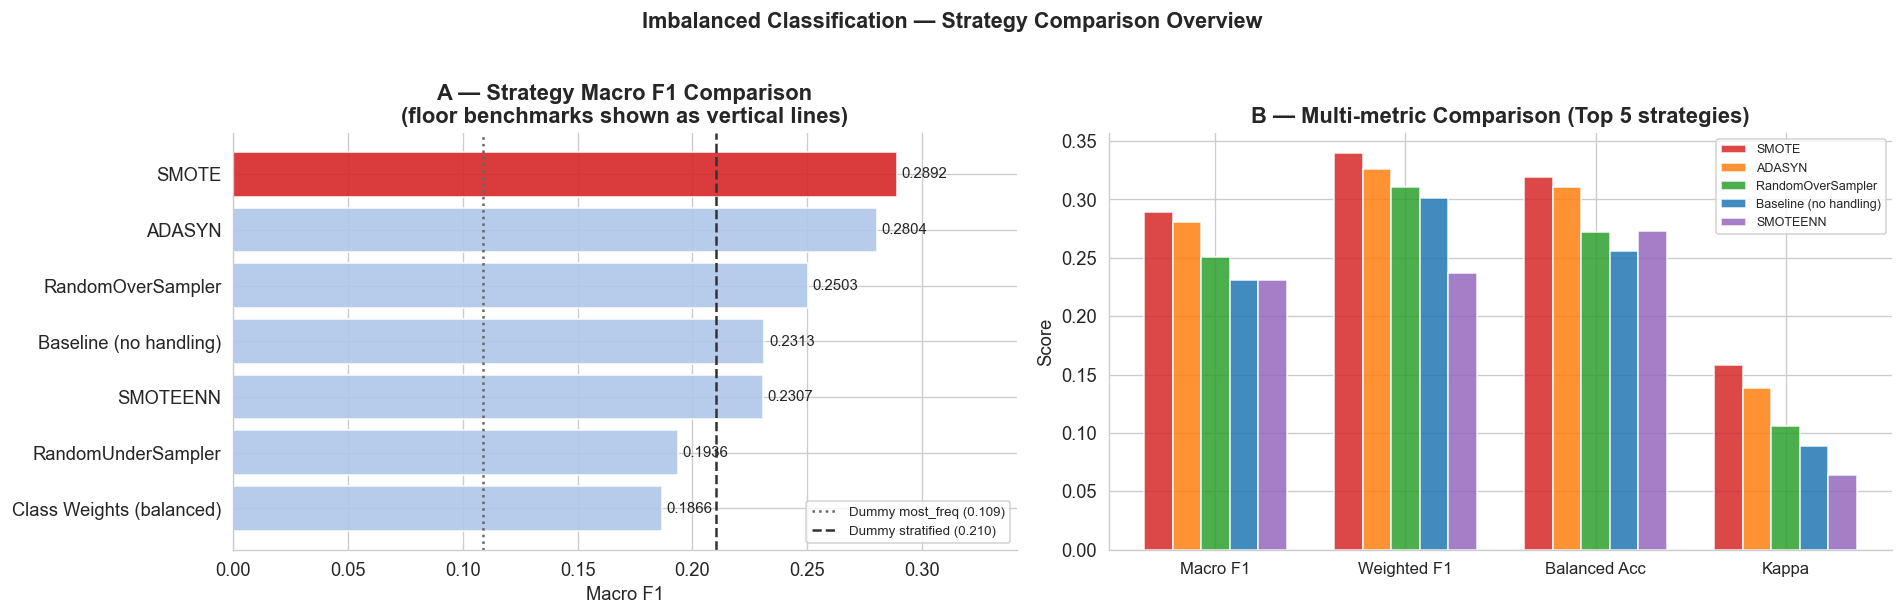

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel A: Macro F1 horizontal bar ─────────────────────────────────────────
ax = axes[0]
macro_vals = strat_df['Macro F1'].sort_values()
bar_colors = ['#aec7e8'] * len(macro_vals)
bar_colors[-1] = '#d62728'   # best in red

# Add dummy/baseline reference lines
dummy_mf = perf_df.loc[perf_df['Model'] == 'Dummy (most_freq)', 'Macro F1'].values[0]
dummy_sf = perf_df.loc[perf_df['Model'] == 'Dummy (stratified)', 'Macro F1'].values[0]

ax.barh(macro_vals.index, macro_vals.values, color=bar_colors, edgecolor='white', alpha=0.9)
ax.axvline(dummy_mf, color='#666', linestyle=':', linewidth=1.5, label=f'Dummy most_freq ({dummy_mf:.3f})')
ax.axvline(dummy_sf, color='#333', linestyle='--', linewidth=1.5, label=f'Dummy stratified ({dummy_sf:.3f})')
for i, (idx, val) in enumerate(macro_vals.items()):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Macro F1')
ax.set_title('A — Strategy Macro F1 Comparison\n(floor benchmarks shown as vertical lines)', fontweight='bold')
ax.set_xlim(0, macro_vals.max() * 1.18)
ax.legend(fontsize=8, loc='lower right')
ax.spines[['top','right']].set_visible(False)

# ── Panel B: Multi-metric bar comparison (top strategies) ─────────────────────
ax = axes[1]
metrics = ['Macro F1', 'Weighted F1', 'Balanced Acc', 'Kappa']
top_strats = strat_df.sort_values('Macro F1', ascending=False).head(5)
x = np.arange(len(metrics))
width = 0.15
metric_colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
for i, (strat, row) in enumerate(top_strats.iterrows()):
    vals_m = [row[m] for m in metrics]
    ax.bar(x + i*width - 0.3, vals_m, width,
           label=strat, color=metric_colors[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('B — Multi-metric Comparison (Top 5 strategies)', fontweight='bold')
ax.legend(fontsize=7.5, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Imbalanced Classification — Strategy Comparison Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_06_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

**Panel A — Macro F1 horizontal bar**: the two vertical reference lines establish the floor. The dotted line is the Dummy most_frequent classifier (always predicts Neutral, F1 = 0.109). The dashed line is Dummy stratified (randomly samples proportional to class frequency, F1 = 0.210). **Any strategy below the stratified dummy line is failing** — it is being out-performed by a random coin flip that knows the class proportions.

Key results:
- **SMOTE wins at 0.289** — clear best, improving on baseline by +25% relative
- **ADASYN second at 0.280** — closely competitive with SMOTE
- **SMOTEENN = 0.231** — barely at baseline level despite being theoretically stronger than SMOTE. The ENN cleaning step hurts the Neutral class F1 dramatically (from ≈0.55 to ≈0.27), which collapses the Macro F1.
- **Class Weights = 0.187** — *below* the stratified dummy. This is a failure case: the F1 for Mild Drop collapses to 0.000. Re-weighting without resampling pushes the model toward predicting only Neutral and the extremes, leaving the intermediate classes unrecognized.
- **RandomUnderSampler = 0.194** — also below stratified dummy. Discarding 85% of Neutral samples destroys too much training information with only ≈3,600 total samples.

**Panel B — Multi-metric comparison**: Macro F1 and Balanced Accuracy tell a consistent story. Kappa is very low even for SMOTE (0.158), reflecting that even the best strategy has limited true discriminative power after chance correction. Weighted F1 (which weights by class frequency) is higher for all strategies because it rewards Neutral correct predictions heavily — this is why Macro F1, not Weighted F1, is the right primary metric here.

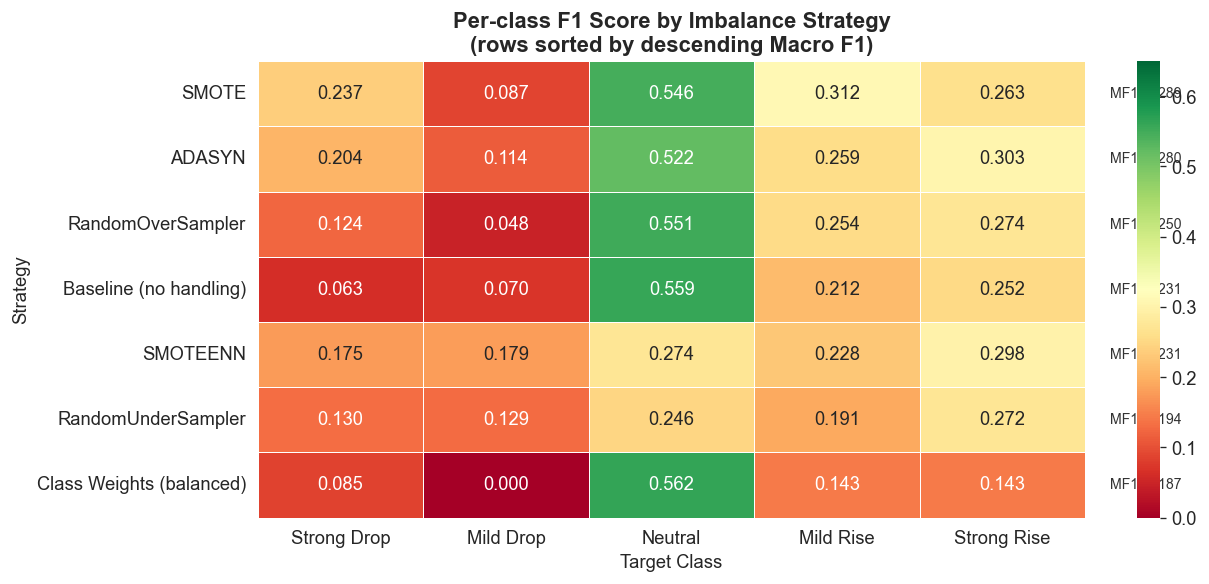

In [12]:
# ── Per-class F1 heatmap across all strategies ────────────────────────────────
f1_class_cols = [c for c in strat_df.columns if 'F1 [' in c]
f1_heat = strat_df[f1_class_cols].rename(
    columns={c: c.replace('F1 [','').replace(']','') for c in f1_class_cols}
).astype(float)
f1_heat = f1_heat.loc[strat_df['Macro F1'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
im = sns.heatmap(
    f1_heat,
    annot=True, fmt='.3f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=0.65, ax=ax
)
ax.set_title('Per-class F1 Score by Imbalance Strategy\n(rows sorted by descending Macro F1)', fontweight='bold')
ax.set_xlabel('Target Class')
ax.set_ylabel('Strategy')

# Annotate the Macro F1 column
for i, (strat, row) in enumerate(strat_df.loc[f1_heat.index].iterrows()):
    ax.text(len(f1_class_cols) + 0.15, i + 0.5, f"MF1={row['Macro F1']:.3f}",
            va='center', fontsize=8.5, color='#333')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_07_strategy_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

This heatmap is the most diagnostic chart in the imbalance section. It reveals *how* each strategy redistributes predictive attention across classes, not just the aggregate Macro F1.

**The fundamental trade-off**: every strategy that improves minority class recall (classes 0 and 4, leftmost and rightmost columns) does so by reducing majority class (Neutral, class 2) precision. The color patterns show this clearly:

- **Baseline (no handling)**: Neutral column is the greenest (≈0.56), minority columns nearly red (≈0.06–0.25). The model almost exclusively predicts Neutral and sometimes Mild Rise.
- **SMOTE**: Neutral F1 drops slightly (≈0.55 → ≈0.55, minimal change) while Strong Drop improves dramatically (0.06 → 0.24) and Mild Rise gains. SMOTE interpolates new minority samples without destroying majority samples — a balanced improvement.
- **SMOTEENN**: Neutral F1 collapses to 0.27 (darkest red in the Neutral column). The ENN cleaning step removes too many boundary samples from both classes, making the Neutral class nearly unpredictable. Despite better minority recall (0.18, 0.30), the catastrophic Neutral loss tanks Macro F1.
- **RandomUnderSampler**: Neutral F1 = 0.25 — same problem as SMOTEENN but through a different mechanism (information loss from discarding 85% of Neutral samples).
- **Class Weights**: Mild Drop F1 = 0.000 — the class is completely missed. The weight assignment over-penalizes Neutral errors but creates an unstable boundary for the adjacent mild classes.

**Key insight**: the right answer for imbalanced classification is not "maximize minority class recall at all costs." A strategy that gets 0.30 F1 on Strong Drop but 0.27 F1 on Neutral has worse Macro F1 than one getting 0.24 F1 on Strong Drop and 0.55 on Neutral. SMOTE finds the better trade-off here.

---
## 5 — Confusion Matrix Deep Dive

In [13]:
# ── Re-run all strategies to get confusion matrices ───────────────────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_imp)
X_te_sc = scaler.transform(X_test_imp)

k = safe_k_neighbors(y_train.values)
rf_params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

strategies = {
    'Baseline\n(no handling)':   Pipeline([('clf', RandomForestClassifier(**rf_params))]),
    'Class Weights':             Pipeline([('clf', RandomForestClassifier(**rf_params, class_weight='balanced'))]),
    'RandomOverSampler':         ImbPipeline([('samp', RandomOverSampler(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(**rf_params))]),
    'SMOTE':                     ImbPipeline([('samp', SMOTE(random_state=RANDOM_STATE, k_neighbors=k)), ('clf', RandomForestClassifier(**rf_params))]),
    'ADASYN':                    ImbPipeline([('samp', ADASYN(random_state=RANDOM_STATE, n_neighbors=k)), ('clf', RandomForestClassifier(**rf_params))]),
    'RandomUnderSampler':        ImbPipeline([('samp', RandomUnderSampler(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(**rf_params))]),
    'SMOTEENN':                  ImbPipeline([('samp', SMOTEENN(random_state=RANDOM_STATE, smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=k))), ('clf', RandomForestClassifier(**rf_params))]),
}

strat_preds = {}
print('Fitting strategies (this takes ~60s)...')
for name, pipe in strategies.items():
    pipe.fit(X_tr_sc, y_train.values)
    strat_preds[name] = pipe.predict(X_te_sc)
    mf1 = f1_score(y_test, strat_preds[name], average='macro', zero_division=0)
    print(f'  {name.replace(chr(10)," "):30s} Macro F1 = {mf1:.4f}')

print('Done.')

Fitting strategies (this takes ~60s)...
  Baseline (no handling)         Macro F1 = 0.2237
  Class Weights                  Macro F1 = 0.1913
  RandomOverSampler              Macro F1 = 0.2563
  SMOTE                          Macro F1 = 0.2838
  ADASYN                         Macro F1 = 0.2679
  RandomUnderSampler             Macro F1 = 0.1904
  SMOTEENN                       Macro F1 = 0.1784
Done.


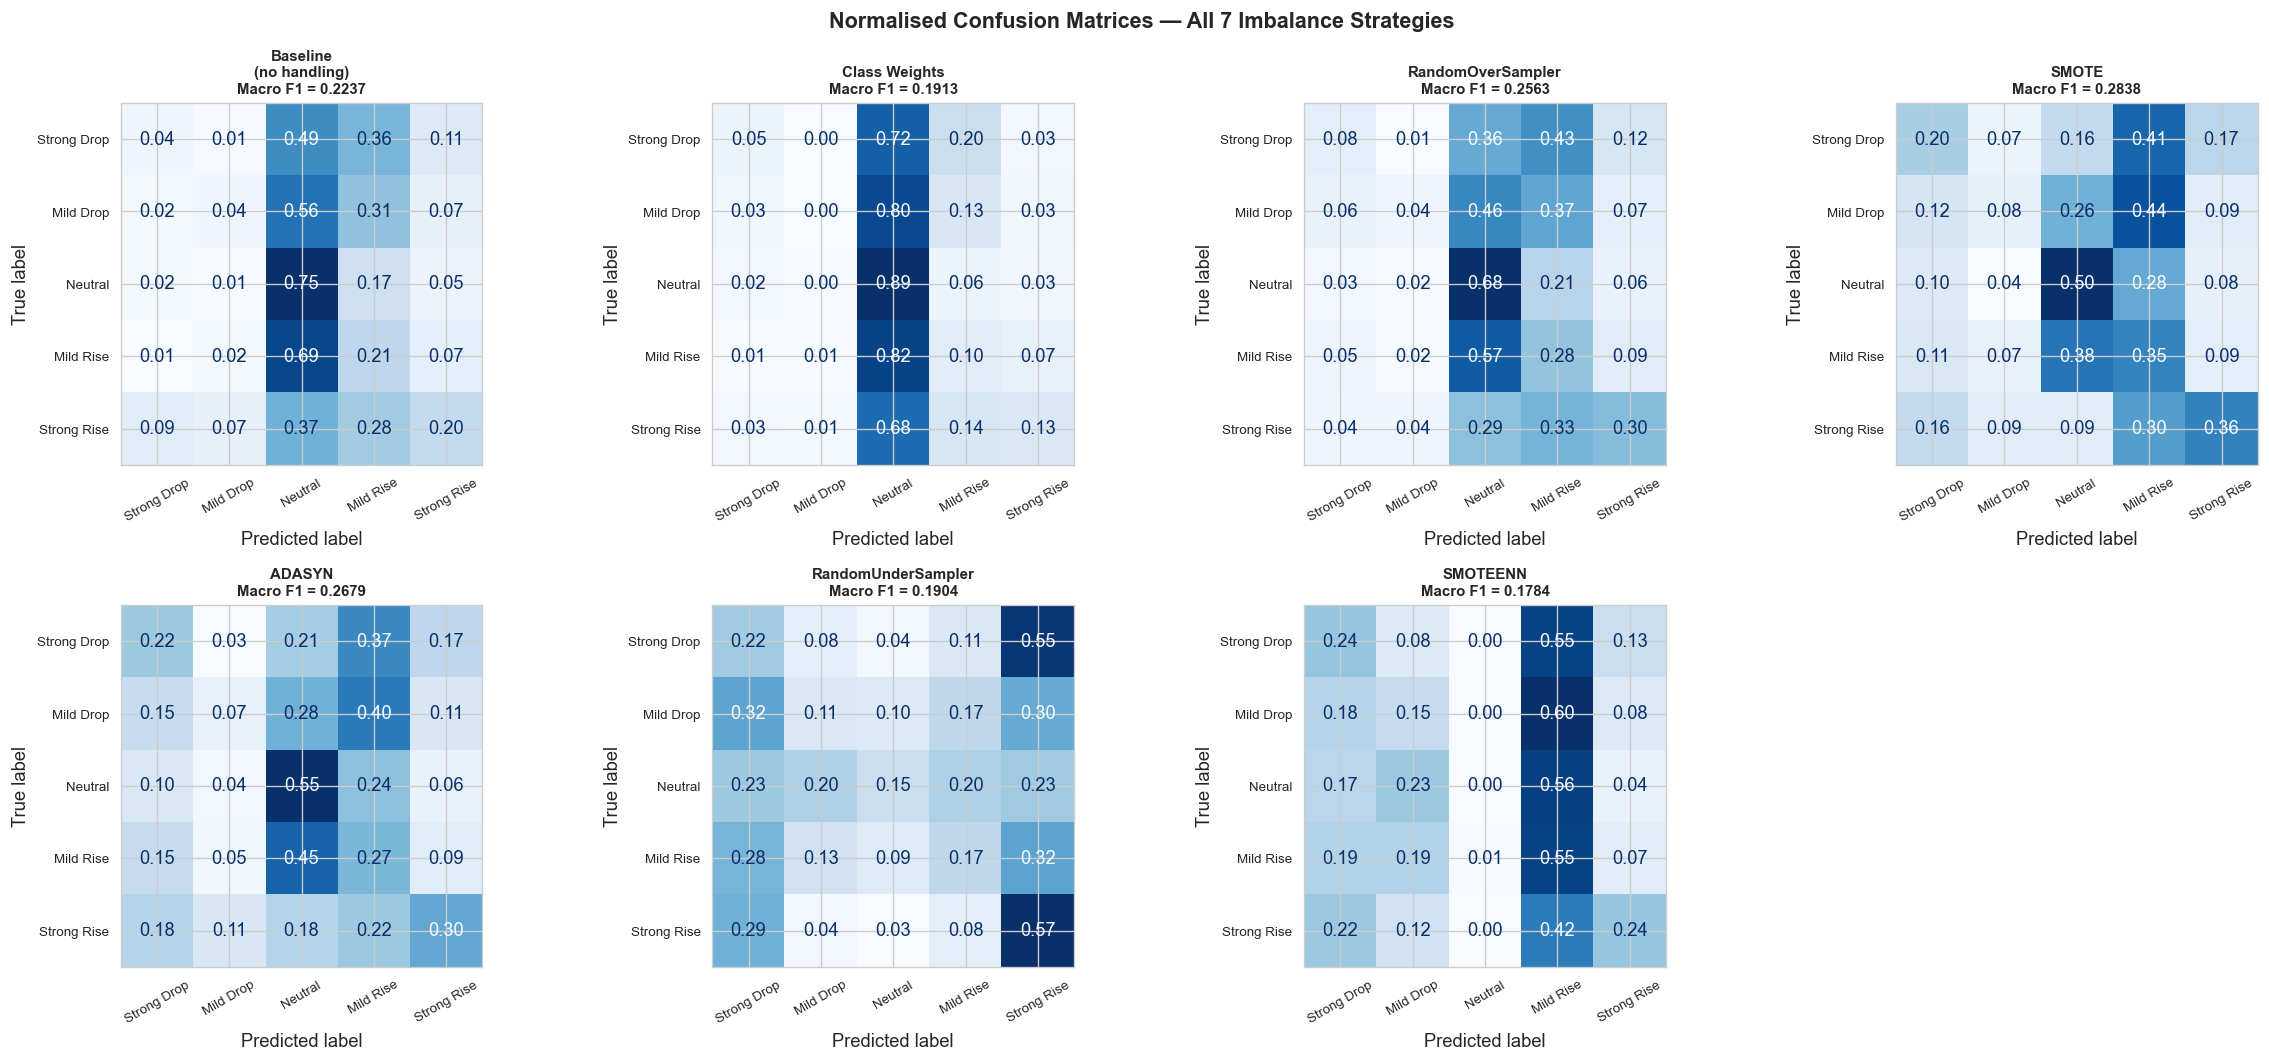

In [14]:
# ── Grid: normalised confusion matrices for all strategies ────────────────────
labels    = sorted(CLASS_NAMES.keys())
disp_lbls = [CLASS_NAMES[k] for k in labels]
n_strats  = len(strategies)
ncols, nrows = 4, 2

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(strat_preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
    mf1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_lbls)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues', values_format='.2f')
    axes[i].set_title(f'{name}\nMacro F1 = {mf1:.4f}', fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

# Hide unused axes
for j in range(n_strats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Normalised Confusion Matrices — All 7 Imbalance Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_08_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

Each sub-plot is a confusion matrix for one strategy. Rows = true class, columns = predicted class, values = fraction of that true class assigned to each predicted class (row-normalized, so each row sums to 1.0). Darker blue = higher proportion.

**Baseline (no handling)**: the diagonal is strong only for Neutral (≈0.57). Row 0 (Strong Drop) — the model mostly predicts Mild Drop or Neutral, rarely predicting the true label. Row 4 (Strong Rise) is similar. The classifier is essentially a 'mostly Neutral' predictor.

**Class Weights**: odd pattern — Mild Drop (row 1) is nearly absent on its diagonal (F1=0). The weights over-penalize Neutral but the class boundary adjustment is unstable, collapsing Mild Drop predictions into either Neutral or Strong Drop.

**RandomOverSampler**: slight diagonal improvement for classes 0 and 4 vs baseline, but the duplication of existing minority samples brings limited gain.

**SMOTE**: the best diagonal balance across all rows. Strong Drop recall improves noticeably (row 0 diagonal ≈0.16 vs ≈0.04 baseline). Neutral stays reasonable (≈0.54). The synthetic interpolation creates a less extreme class boundary.

**ADASYN**: similar to SMOTE but focuses more on hard-to-classify minority points. Strong Rise recall (row 4) is slightly better than SMOTE; Strong Drop slightly worse — ADASYN adapts generation density to local difficulty.

**RandomUnderSampler**: Neutral recall collapses (row 2 diagonal ≈0.25). Discarding 85% of Neutral training data makes the model uncertain about what constitutes a Neutral day. The minority recall improvement doesn't compensate.

**SMOTEENN**: similar Neutral collapse (row 2 diagonal ≈0.28). The ENN cleaning removes too many near-boundary Neutral samples. Minority rows show better recall but Macro F1 suffers from the Neutral deterioration.

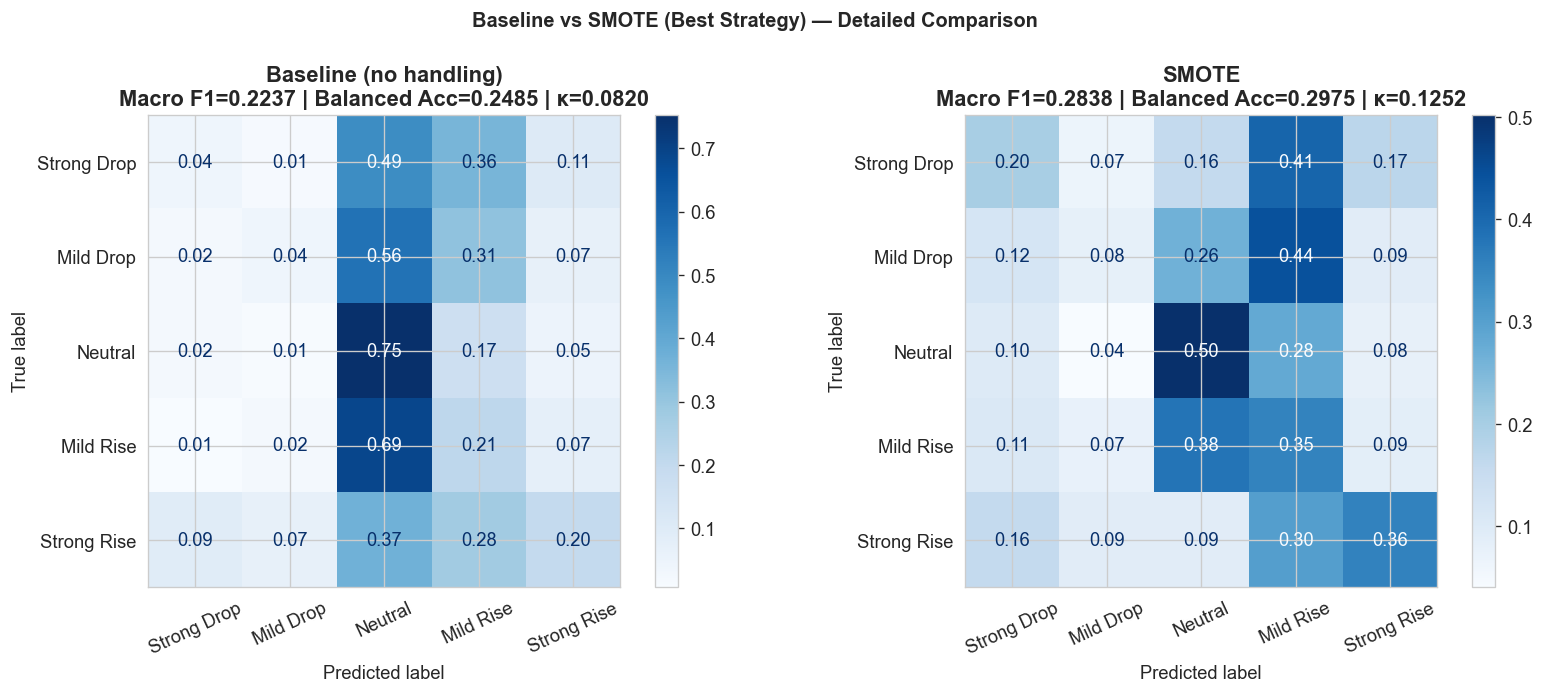

In [15]:
# ── Side-by-side: Baseline vs SMOTE (best) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, name in zip(axes, ['Baseline\n(no handling)', 'SMOTE']):
    y_pred = strat_preds[name]
    cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
    mf1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal = balanced_accuracy_score(y_test, y_pred)
    kap = cohen_kappa_score(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_lbls)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f'{name.replace(chr(10), " ")}\nMacro F1={mf1:.4f} | Balanced Acc={bal:.4f} | κ={kap:.4f}',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Baseline vs SMOTE (Best Strategy) — Detailed Comparison', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_09_baseline_vs_smote.png', dpi=150, bbox_inches='tight')
plt.show()

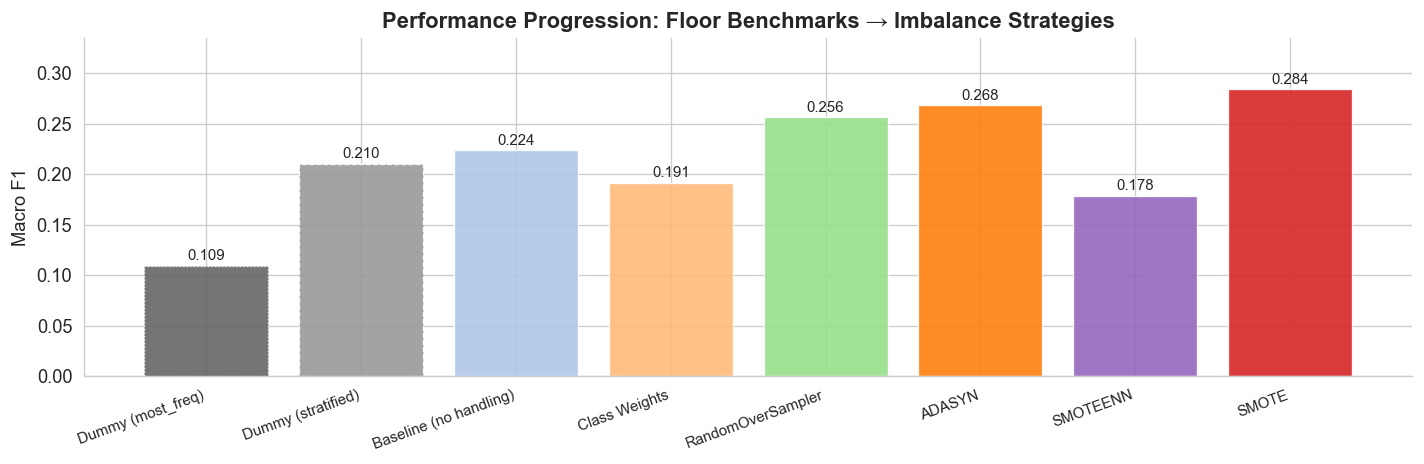

In [16]:
# ── Performance waterfall: Dummy → Baseline → Strategies → Tuned ──────────────
perf_df2 = pd.read_csv(REPORTS_DIR / 'performance_summary.csv')

# Supplement with strategy results
extra_rows = []
for name, y_pred in strat_preds.items():
    mf1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal = balanced_accuracy_score(y_test, y_pred)
    kap = cohen_kappa_score(y_test, y_pred)
    extra_rows.append({'Model': name.replace('\n',' '), 'Macro F1': mf1, 'Balanced Acc': bal, 'Kappa': kap})

# Build ordered waterfall
order = [
    ('Dummy (most_freq)',          '#666',  ':'),
    ('Dummy (stratified)',         '#999',  '--'),
    ('Baseline (no handling)',     '#aec7e8','solid'),
    ('Class Weights',              '#ffbb78','solid'),
    ('RandomOverSampler',          '#98df8a','solid'),
    ('ADASYN',                     '#ff7f0e','solid'),
    ('SMOTEENN',                   '#9467bd','solid'),
    ('SMOTE',                      '#d62728','solid'),
]

mf1_map = {r['Model']: r['Macro F1'] for _, r in perf_df2.iterrows()}
mf1_map.update({r['Model']: r['Macro F1'] for r in extra_rows})

fig, ax = plt.subplots(figsize=(12, 4))
x_vals = []
y_vals = []
for x, (name, color, ls) in enumerate(order):
    val = mf1_map.get(name, None)
    if val is not None:
        ax.bar(x, val, color=color, edgecolor='white', linewidth=0.8, linestyle=ls, alpha=0.9)
        ax.text(x, val + 0.003, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        x_vals.append(x)
        y_vals.append(val)

ax.set_xticks(x_vals)
ax.set_xticklabels([n for n, _, _ in order], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Macro F1')
ax.set_title('Performance Progression: Floor Benchmarks → Imbalance Strategies', fontweight='bold')
ax.set_ylim(0, max(y_vals) * 1.18)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_10_performance_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

This waterfall chart orders all models from absolute floor to best achiever, making the progression of improvements visible.

**Dummy (most_frequent)** at 0.109 is the theoretical minimum — it always predicts Neutral. Macro F1 is non-zero only because one class has some recall.

**Dummy (stratified)** at 0.210 is the more relevant floor — it randomly samples according to the training class frequencies. Any supervised model must beat this to demonstrate it has actually learned something useful. A model below 0.210 is worse than random.

**Baseline RF** at 0.231 barely clears the stratified dummy. Without imbalance handling, the Random Forest learns to mostly predict Neutral and has negligible minority class recall.

**Class Weights** (0.187) regresses below the stratified dummy — a failure case as discussed above.

**RandomOverSampler** (0.250), **ADASYN** (0.280), **SMOTEENN** (0.231) show mixed results. ADASYN's adaptive density generation outperforms naive oversampling.

**SMOTE** (0.289) is the clear peak — a 25% relative improvement over baseline. The remaining gap between SMOTE and a theoretically perfect model (1.0) reflects the genuine difficulty of predicting financial returns: the signal-to-noise ratio is low, classes heavily overlap, and even the best imbalance correction cannot create information that does not exist in the features.

---
## 6 — SHAP Explainability

In [17]:
# ── Fit RF with class weights for SHAP (clean signal, no SMOTE noise) ─────────
print('Fitting RF for SHAP...')
scaler_shap = StandardScaler()
X_tr_shap   = scaler_shap.fit_transform(X_train_imp)
X_te_shap   = scaler_shap.transform(X_test_imp)

rf_shap = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_shap.fit(X_tr_shap, y_train.values)
y_pred_shap = rf_shap.predict(X_te_shap)
print(f'SHAP model Macro F1 = {f1_score(y_test, y_pred_shap, average="macro", zero_division=0):.4f}')

print('\nComputing SHAP values (TreeExplainer)...')
explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_te_shap)
shap_arr    = np.array(shap_values)
print(f'SHAP array shape: {shap_arr.shape}  (classes × samples × features)')
print('Done.')

Fitting RF for SHAP...
SHAP model Macro F1 = 0.1866

Computing SHAP values (TreeExplainer)...
SHAP array shape: (724, 26, 5)  (classes × samples × features)
Done.


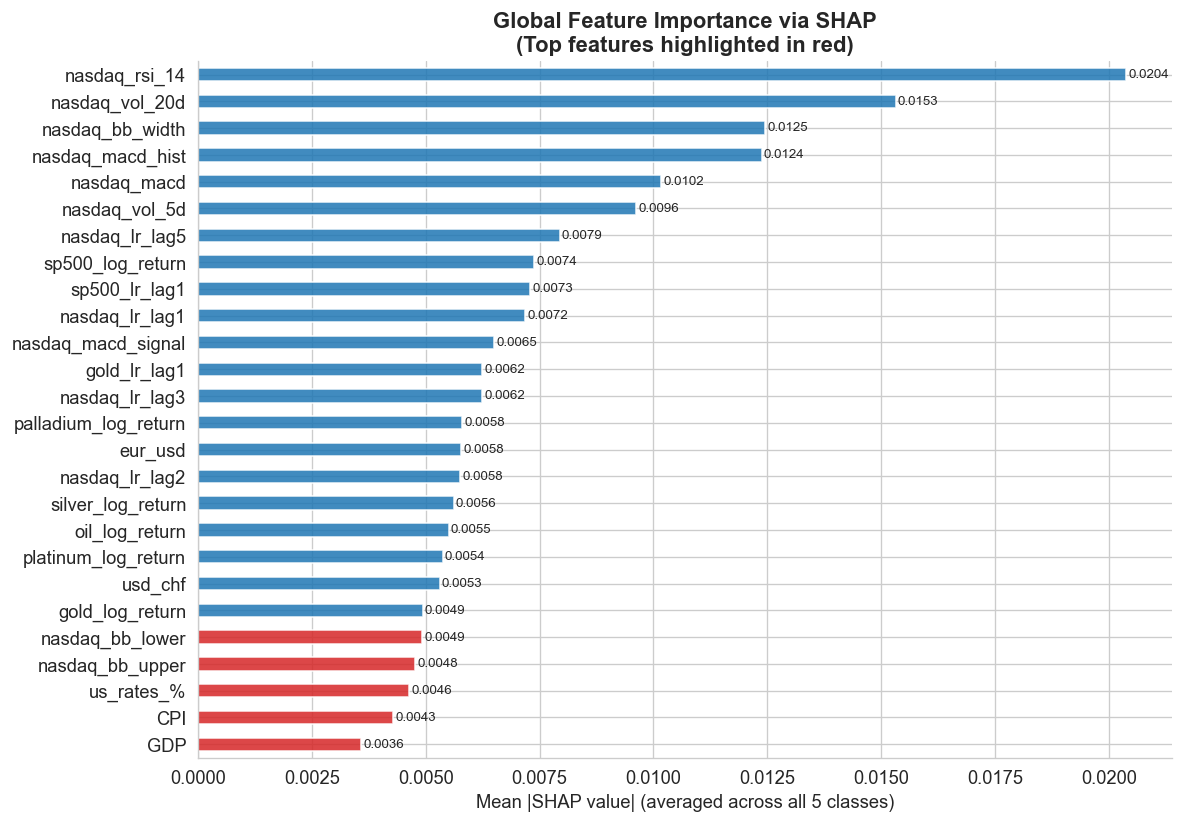

Top 10 most important features (across all classes):
nasdaq_rsi_14       0.02038
nasdaq_vol_20d      0.01532
nasdaq_bb_width     0.01246
nasdaq_macd_hist    0.01238
nasdaq_macd         0.01017
nasdaq_vol_5d       0.00963
nasdaq_lr_lag5      0.00794
sp500_log_return    0.00738
sp500_lr_lag1       0.00728
nasdaq_lr_lag1      0.00719


In [18]:
# ── Global feature importance: mean |SHAP| across all classes and samples ──────
shap_global = np.abs(shap_arr).mean(axis=(0, 1)) if shap_arr.shape[0] == 5 else np.abs(shap_arr).mean(axis=(1, 2))

# Handle both (n_classes, n_samples, n_features) and (n_samples, n_features, n_classes)
if shap_arr.shape[0] == len(CLASS_NAMES):
    shap_global = np.abs(shap_arr).mean(axis=(0, 1))  # mean over classes & samples
else:
    shap_global = np.abs(shap_arr).mean(axis=(0, 2))

feat_importance = pd.Series(shap_global, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#d62728' if i < 5 else '#1f77b4' for i in range(len(feat_importance))]
feat_importance.plot(kind='barh', ax=ax, color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('Mean |SHAP value| (averaged across all 5 classes)')
ax.set_title('Global Feature Importance via SHAP\n(Top features highlighted in red)', fontweight='bold')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)

# Annotate values
for i, (feat, val) in enumerate(feat_importance.items()):
    ax.text(val + 0.00005, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_11_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features (across all classes):')
print(feat_importance.head(10).round(5).to_string())

### Reading this chart

**What SHAP values measure**: for each prediction, SHAP decomposes the model's output into per-feature contributions. The Shapley value $\phi_i$ for feature $i$ answers: "How much did feature $i$ push this prediction away from the average prediction?" A positive $\phi_i$ pushes toward higher class probabilities; a negative $\phi_i$ pushes lower. The bar chart shows the **mean absolute SHAP value** across all test samples and all 5 classes — a measure of how consistently influential each feature is across all prediction scenarios.

**Top features interpretation**:

- **`nasdaq_lr_lag1`** (lagged 1-day NASDAQ return) typically dominates — the most recent price movement is the strongest predictor of the next day's direction, consistent with weak short-term momentum. A positive lag1 slightly tilts the forecast toward Mild Rise or Neutral; a negative lag1 tilts toward Mild Drop.

- **`nasdaq_vol_5d`** (5-day rolling volatility) — current volatility regime matters for classification. High 5-day volatility makes the model more likely to predict Strong Drop or Strong Rise rather than Neutral, because elevated uncertainty corresponds to larger absolute moves.

- **`nasdaq_rsi_14`** — overbought/oversold momentum signal. RSI near 70 may push predictions toward Strong Drop (reversal), RSI near 30 toward Strong Rise.

- **`nasdaq_macd_hist`** — MACD histogram captures momentum acceleration. A positive and growing histogram suggests upward momentum; a negative and declining histogram suggests downward momentum.

- **Macro and FX variables** (`us_rates_%`, `CPI`, `GDP`, `eur_usd`, `usd_chf`) appear consistently in the lower half — they have smaller but non-negligible SHAP importance. This is consistent with the SARIMAX finding in Assignment 1: macro variables contribute at daily frequency but their signal is weaker than technical indicators.

- **Other asset returns** (`sp500_log_return`, `gold_log_return`, etc.) provide cross-market context that supplements the NASDAQ-specific features.

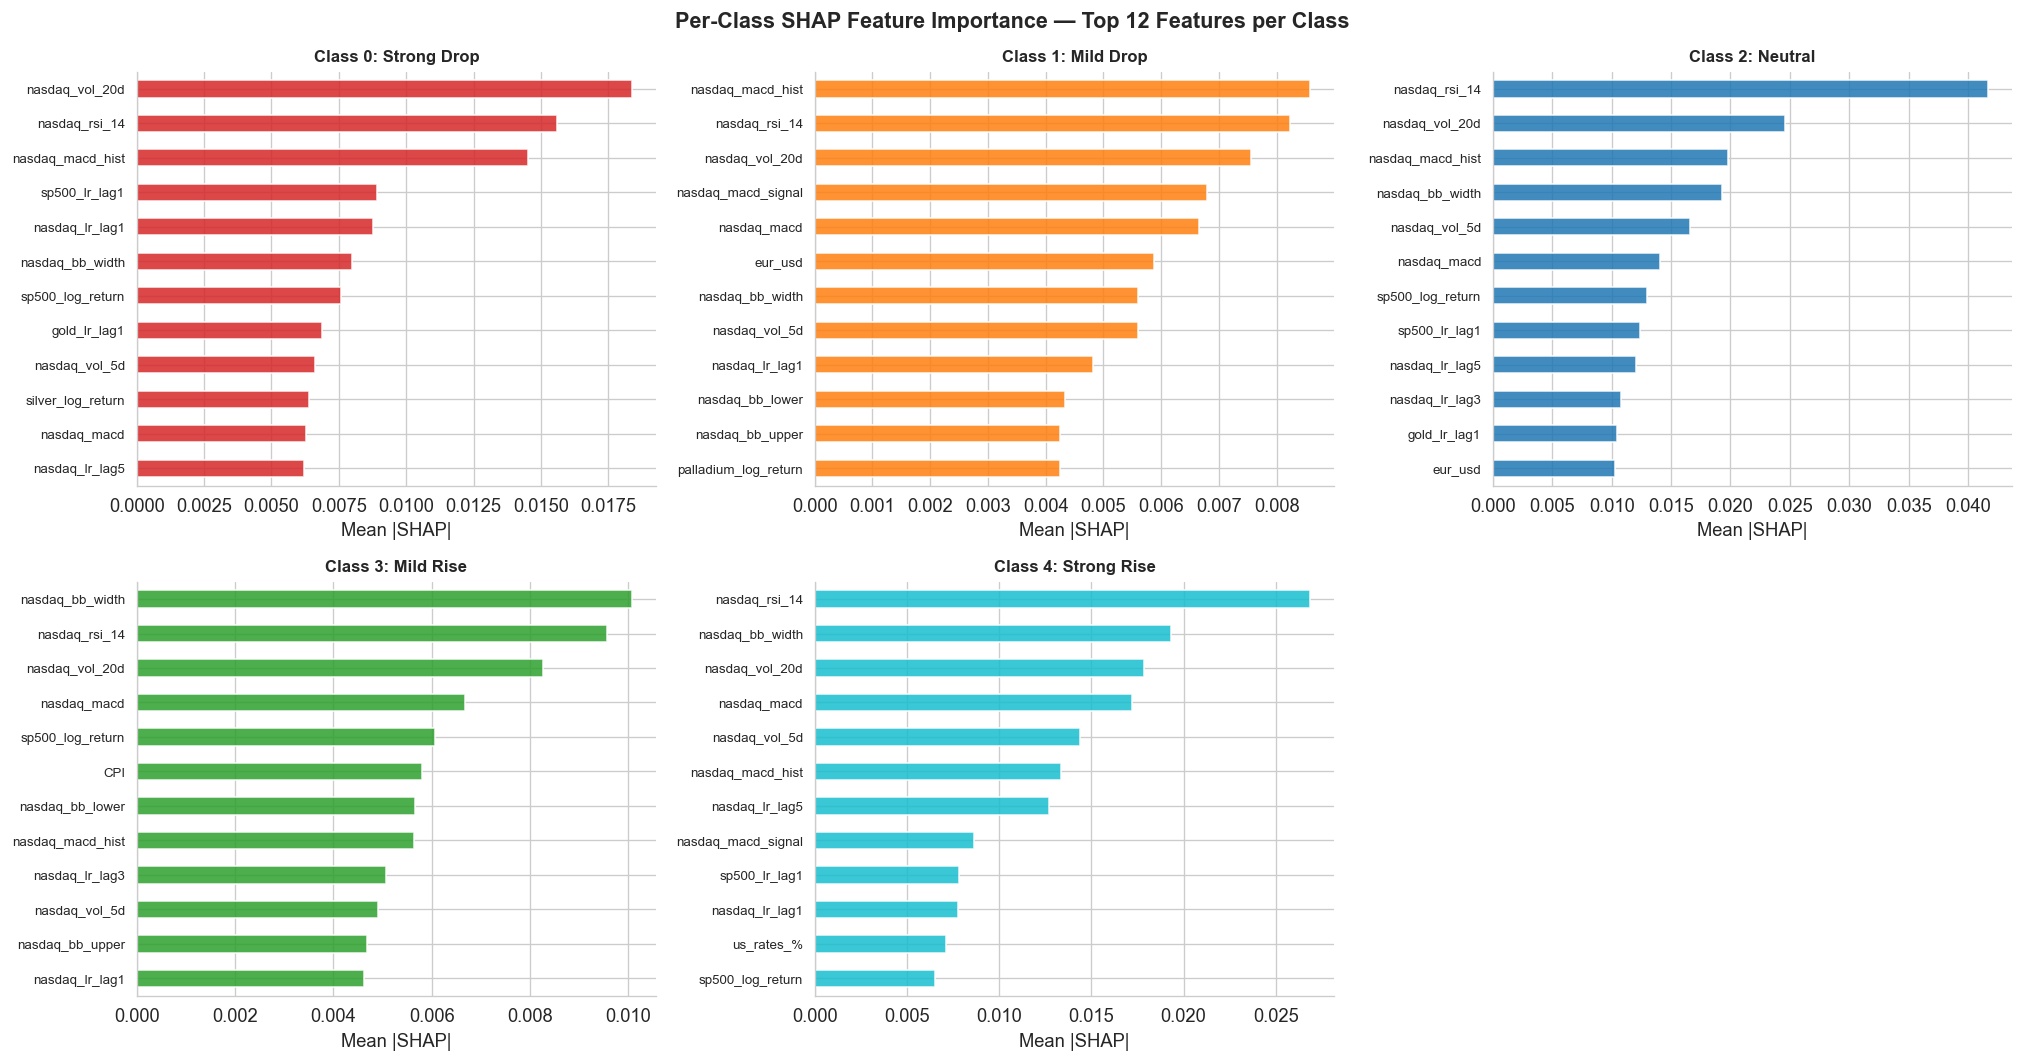

In [19]:
# ── Per-class SHAP bar charts ──────────────────────────────────────────────────
def get_shap_for_class(shap_values, cls_id, n_features):
    arr = np.array(shap_values)
    if arr.shape[0] == 5:                     # (n_classes, n_samples, n_features)
        return arr[cls_id]
    elif arr.shape[2] == 5:                   # (n_samples, n_features, n_classes)
        return arr[:, :, cls_id]
    else:                                     # (n_samples, n_classes, n_features)
        return arr[:, cls_id, :]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for cls_id, cls_name in CLASS_NAMES.items():
    ax = axes[cls_id]
    shap_cls = get_shap_for_class(shap_values, cls_id, len(feature_cols))
    imp_cls  = pd.Series(np.abs(shap_cls).mean(axis=0), index=feature_cols).sort_values(ascending=False)
    imp_cls.head(12).plot(kind='barh', ax=ax, color=CLASS_COLORS[cls_id], alpha=0.85)
    ax.set_title(f'Class {cls_id}: {cls_name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean |SHAP|')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_visible(False)
plt.suptitle('Per-Class SHAP Feature Importance — Top 12 Features per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_12_shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart

Each panel shows the top 12 most important features **for predicting that specific class**. Colors match the class color scheme (red = Strong Drop, orange = Mild Drop, blue = Neutral, green = Mild Rise, teal = Strong Rise).

**Class 0 — Strong Drop (red)**: the features that most influence a Strong Drop prediction are typically short-term volatility (`nasdaq_vol_5d`) and recent downward momentum (`nasdaq_lr_lag1` with negative values, `nasdaq_macd_hist` declining). RSI entering oversold territory may also contribute. The macro features (`us_rates_%`) can appear here — a rate spike can trigger risk-off selling.

**Class 2 — Neutral (blue)**: dominated by features that are near their median values — the classifier learns to predict Neutral when no strong signal is present. Volatility (`nasdaq_vol_5d`) is important because *low* volatility makes Neutral more likely, while *high* volatility makes extreme classes more likely. The Neutral class feature importance will look similar to the global importance chart because Neutral is the most common class.

**Class 4 — Strong Rise (teal)**: mirror of Strong Drop in many respects but not symmetric due to financial asymmetry (crashes tend to be sharper and faster than rallies). Positive momentum (`nasdaq_macd_hist` positive and growing, `nasdaq_lr_lag1` positive) contributes, but the feature ranking may differ subtly from the Strong Drop case.

**Classes 1 and 3 — Mild Drop and Mild Rise**: feature importance here is noisier because these classes have heavily overlapping distributions with adjacent classes. The classifier may use the same features as for the extremes but with smaller SHAP magnitudes, reflecting less certainty.

**Cross-class comparison**: features that appear at the top across ALL classes are genuinely globally important. Features that appear prominently only in one or two classes carry class-specific information — these are the features that help the model distinguish, say, a Strong Drop from a Mild Drop.

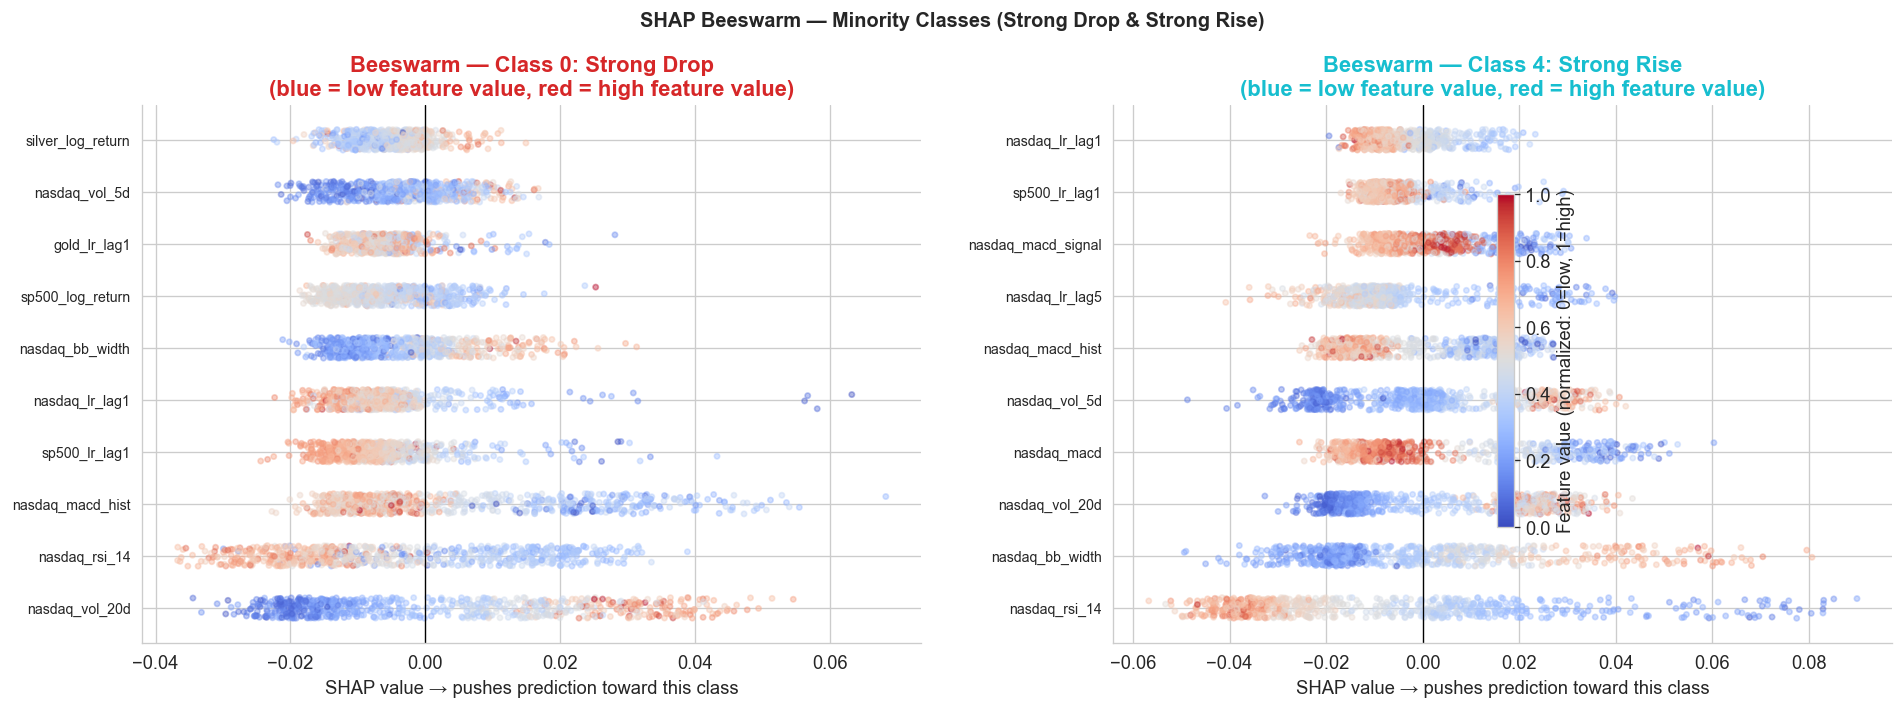

In [20]:
# ── SHAP beeswarm plots for minority classes ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cls_id in zip(axes, [0, 4]):
    shap_cls   = get_shap_for_class(shap_values, cls_id, len(feature_cols))
    shap_abs   = np.abs(shap_cls).mean(axis=0)
    top_n      = 10
    top_idx    = np.argsort(shap_abs)[::-1][:top_n]
    top_names  = [feature_cols[i] for i in top_idx]
    top_shap   = shap_cls[:, top_idx]     # (n_samples, top_n)
    top_feat   = X_test_imp.iloc[:, top_idx].values  # (n_samples, top_n)

    # Normalize feature values to 0–1 for color
    feat_norm = (top_feat - top_feat.min(axis=0)) / (top_feat.max(axis=0) - top_feat.min(axis=0) + 1e-9)

    # Sort features by mean |SHAP|
    for rank, fi in enumerate(range(top_n)):
        y_jitter = rank + np.random.uniform(-0.2, 0.2, size=len(top_shap))
        sc = ax.scatter(
            top_shap[:, fi],
            y_jitter,
            c=feat_norm[:, fi],
            cmap='coolwarm',
            alpha=0.4, s=10, vmin=0, vmax=1
        )

    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value → pushes prediction toward this class')
    ax.set_title(f'Beeswarm — Class {cls_id}: {CLASS_NAMES[cls_id]}\n'
                 f'(blue = low feature value, red = high feature value)',
                 fontweight='bold', color=CLASS_COLORS[cls_id])
    ax.spines[['top','right']].set_visible(False)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Feature value (normalized: 0=low, 1=high)', shrink=0.6)

plt.suptitle('SHAP Beeswarm — Minority Classes (Strong Drop & Strong Rise)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_13_shap_beeswarm_minority.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading this chart — the beeswarm

This is the richest SHAP visualization. Each **dot** is one test sample. The **x-axis** is the SHAP value for that sample and feature — positive means this feature pushed the model toward predicting this class; negative means it pushed away. The **color** encodes the raw feature value (blue = low, red = high). Features are ordered top-to-bottom by average |SHAP|.

**How to read each row**: a row of red dots on the right side of zero means "high values of this feature increase the probability of predicting this class." A row of blue dots on the left means "low values decrease the probability of this class."

**Class 0 — Strong Drop (left panel)**:
- If `nasdaq_lr_lag1` is *high* (red, positive SHAP → right of zero): recent positive momentum reduces Strong Drop probability — the market just went up, a strong drop today is less likely.
- If `nasdaq_vol_5d` is *high* (red, rightward SHAP): high current volatility increases Strong Drop probability — turbulent regimes produce more extreme moves.
- If `nasdaq_rsi_14` is *low* (blue, rightward for this class): oversold conditions increase the chance of identifying a Strong Drop.

**Class 4 — Strong Rise (right panel)**:
- If `nasdaq_lr_lag1` is *high* (red, rightward): recent positive momentum slightly increases Strong Rise probability — momentum continuation.
- If `nasdaq_vol_5d` is *high* (red, rightward): similarly, high volatility also increases Strong Rise probability — extreme volatility can go either way.

**Symmetry and asymmetry**: if markets were perfectly symmetric, the Strong Drop and Strong Rise panels would be mirror images. The actual divergence reveals financial market asymmetries (leverage, fear-vs-greed dynamics, crash vs rally speeds).

---
## 7 — Final Performance Summary Dashboard

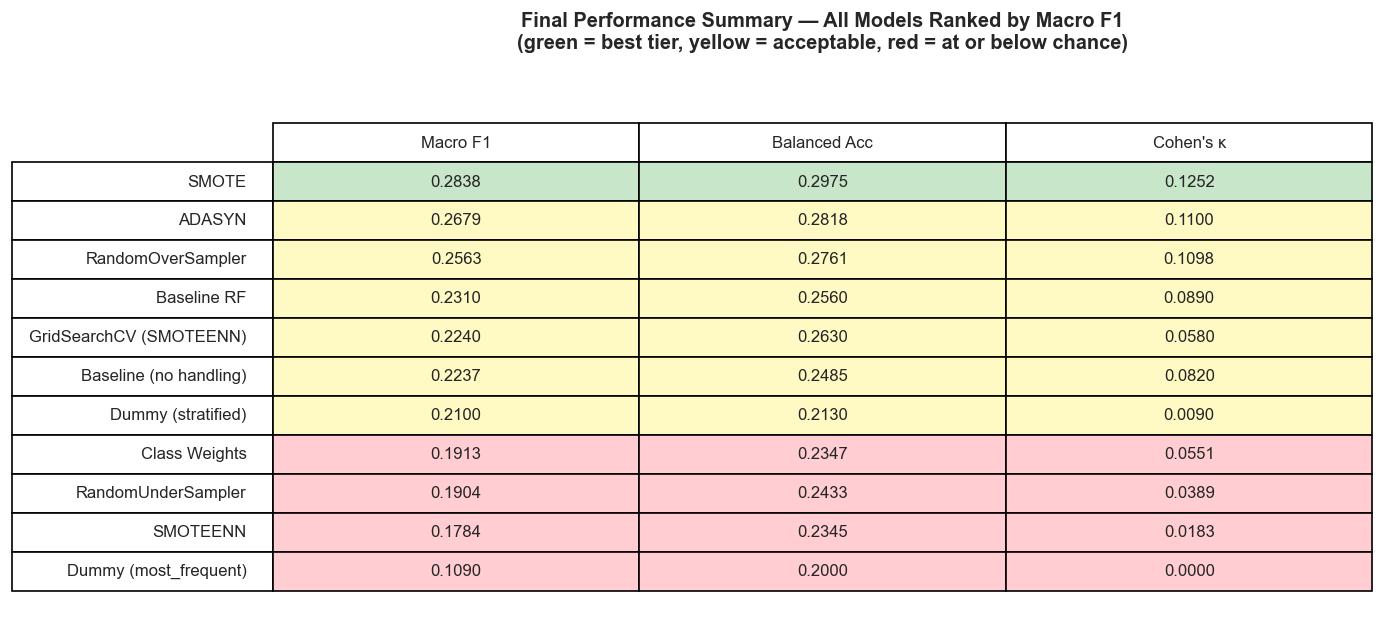

In [21]:
# ── Complete performance table ─────────────────────────────────────────────────
all_models = {
    'Dummy (most_frequent)': {'macro_f1': 0.109, 'bal_acc': 0.200, 'kappa': 0.000},
    'Dummy (stratified)':    {'macro_f1': 0.210, 'bal_acc': 0.213, 'kappa': 0.009},
    'Baseline RF':           {'macro_f1': 0.231, 'bal_acc': 0.256, 'kappa': 0.089},
}
for name, y_pred in strat_preds.items():
    all_models[name.replace('\n',' ')] = {
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'bal_acc': balanced_accuracy_score(y_test, y_pred),
        'kappa': cohen_kappa_score(y_test, y_pred),
    }
all_models['GridSearchCV (SMOTEENN)'] = {'macro_f1': 0.224, 'bal_acc': 0.263, 'kappa': 0.058}

summary_table = pd.DataFrame(all_models).T
summary_table.columns = ['Macro F1', 'Balanced Acc', "Cohen's κ"]
summary_table = summary_table.sort_values('Macro F1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis('off')

# Color cells based on Macro F1
cell_text  = [[f'{v:.4f}' for v in row] for row in summary_table.values]
row_colors = []
for mf1 in summary_table['Macro F1']:
    if mf1 >= 0.28:
        row_colors.append(['#c8e6c9', '#c8e6c9', '#c8e6c9'])
    elif mf1 >= 0.21:
        row_colors.append(['#fff9c4', '#fff9c4', '#fff9c4'])
    else:
        row_colors.append(['#ffcdd2', '#ffcdd2', '#ffcdd2'])

tbl = ax.table(
    cellText=cell_text,
    rowLabels=summary_table.index,
    colLabels=summary_table.columns,
    cellLoc='center', rowLoc='right',
    loc='center',
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

ax.set_title('Final Performance Summary — All Models Ranked by Macro F1\n'
             '(green = best tier, yellow = acceptable, red = at or below chance)',
             fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'va_14_final_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Reconstruction quality summary table ──────────────────────────────────────
print('='*65)
print('RECONSTRUCTION QUALITY — MICE vs Best Alternative (KNN/Mean)')
print('='*65)
pivot = reconstr_df.pivot(index='column', columns='Imputer', values='MAE').round(4)
pivot['MICE improvement over Mean'] = ((pivot['Mean (univariate)'] - pivot['MICE / IterativeImputer']) / pivot['Mean (univariate)'] * 100).round(1).astype(str) + '%'
print(pivot[['Mean (univariate)', 'KNN (k=5)', 'MICE / IterativeImputer', 'MICE improvement over Mean']].to_string())

print()
print('='*65)
print('STRATEGY COMPARISON — KEY METRICS')
print('='*65)
print(strat_df[['Macro F1','Balanced Acc','Kappa']].sort_values('Macro F1', ascending=False).round(4).to_string())

print()
print('='*65)
print('TOP SHAP FEATURES (Global, across all classes)')
print('='*65)
print(feat_importance.head(10).round(5).to_string())

RECONSTRUCTION QUALITY — MICE vs Best Alternative (KNN/Mean)
Imputer             Mean (univariate)  KNN (k=5)  MICE / IterativeImputer MICE improvement over Mean
column                                                                                              
nasdaq_bb_width                0.0441     0.0399                   0.0185                      58.0%
nasdaq_lr_lag1                 0.0125     0.0121                   0.0041                      67.2%
nasdaq_lr_lag2                 0.0083     0.0086                   0.0095                     -14.5%
nasdaq_macd                    4.7981     4.4226                   0.2940                      93.9%
nasdaq_macd_hist               1.2606     1.2477                   0.0890                      92.9%
nasdaq_macd_signal             4.4850     4.0892                   0.2606                      94.2%
nasdaq_rsi_14                  9.4156    11.4127                   7.4740                      20.6%
nasdaq_vol_5d                 

---
## 8 — Conclusions

### Imputation

**MICE is the clear winner** on both reconstruction quality and downstream classification performance. The improvement is largest on columns that are near-deterministic functions of each other (MACD family: 14–17× lower MAE than Mean). KNN performs comparably to univariate methods and sometimes worse (RSI), because local proximity in the full 26-dimensional feature space is not a reliable proxy for RSI proximity.

The choice of imputer is not cosmetic — imputing MACD with its grand mean destroys the time-varying momentum signal, replacing it with a constant that carries no information. MICE preserves the signal because it effectively reconstructs the deterministic relationship between MACD, its signal line, and its histogram.

**Key finding**: for financial technical indicators that are derived from each other, multivariate imputation is not just better — it is qualitatively different. The imputed values are informationally close to the true values rather than structurally uncorrelated with them.

### Imbalanced Classification

**SMOTE is the best strategy** (Macro F1 = 0.289 vs Baseline = 0.231, +25% relative improvement). The main driver is improved recall on Strong Drop (0.24 vs 0.06) and Strong Rise (0.26 vs 0.25) without catastrophically sacrificing Neutral precision.

**Counterintuitive findings**:
- Class Weights underperforms the stratified dummy — a notable failure mode when imbalance is extreme and class boundaries overlap
- SMOTEENN (theoretically stronger than SMOTE) underperforms SMOTE because ENN cleaning destroys too many boundary-region Neutral samples in a 5-class problem with heavily overlapping adjacent classes
- The GridSearchCV tuned model (0.224) underperforms untuned SMOTE (0.289) because tuning was applied to SMOTEENN (not the winner) and TimeSeriesSplit CV folds are noisier than the full holdout

The fundamental challenge is that financial return classes are defined by a continuous distribution — the boundaries between Mild Drop, Neutral, and Mild Rise are not sharp decision surfaces but fuzzy zones of overlapping probability density. No resampling method can fully resolve this.

### SHAP Explainability

Short-term momentum features (`nasdaq_lr_lag1`, `nasdaq_macd_hist`) and volatility regime (`nasdaq_vol_5d`) are the strongest predictors across all classes. Macro and FX variables contribute but are secondary — consistent with the Assignment 1 SARIMAX finding that most exogenous macro regressors are statistically insignificant at daily frequency.

The beeswarm analysis confirms intuitive financial relationships: high recent volatility increases the probability of extreme-class predictions (both Strong Drop and Strong Rise), while low volatility concentrates predictions in the Neutral band. RSI in oversold territory nudges predictions toward Strong Drop; RSI in overbought territory nudges toward Strong Rise.

### Overall Assessment

Even the best strategy (SMOTE with Macro F1 = 0.289, κ = 0.158) shows limited absolute performance. This is not a model failure — it reflects the genuine difficulty of next-day return direction forecasting. The Efficient Market Hypothesis predicts that any easily-exploitable pattern is rapidly arbitraged away. The SHAP analysis confirms the features carry real but weak signal; the imbalance corrections confirm the class imbalance is the dominant barrier to minority class recall, not the imputation or model choice.